<a href="https://colab.research.google.com/github/hariharan-075/ML/blob/main/2420080075_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

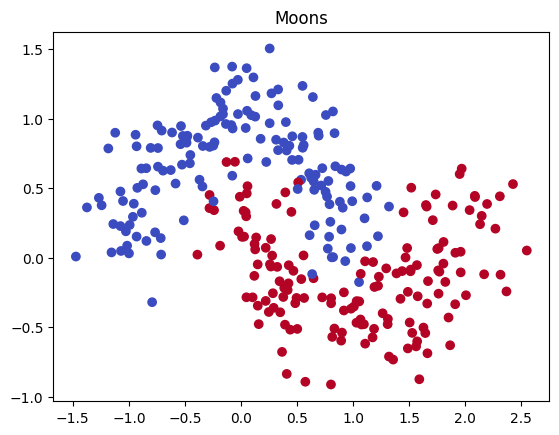

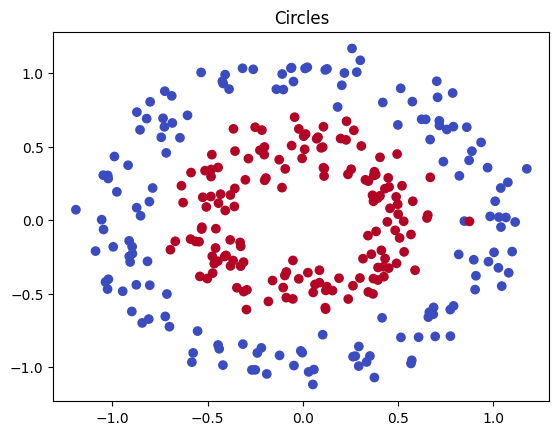

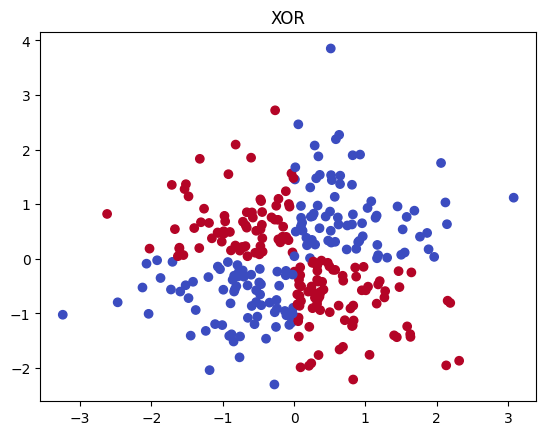

Linear Accuracy: 0.8666666666666667


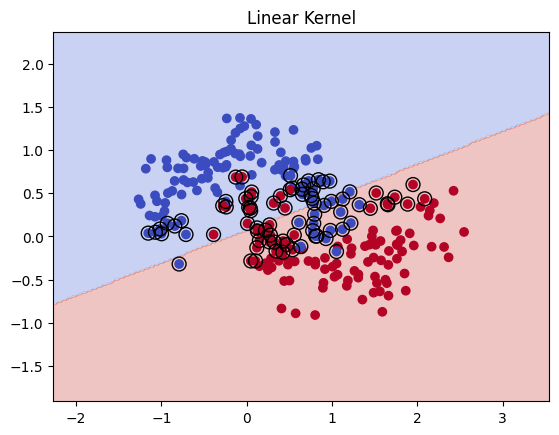

Poly2 Accuracy: 0.8


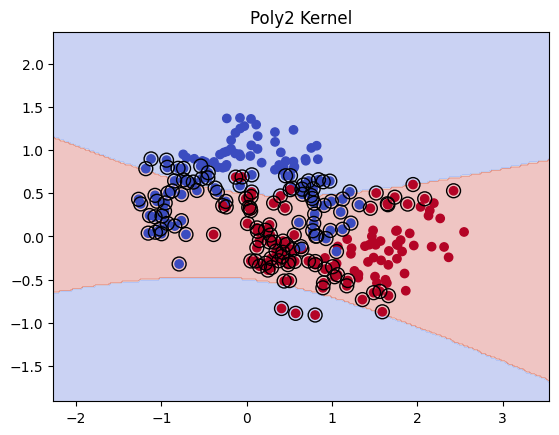

Poly3 Accuracy: 0.9333333333333333


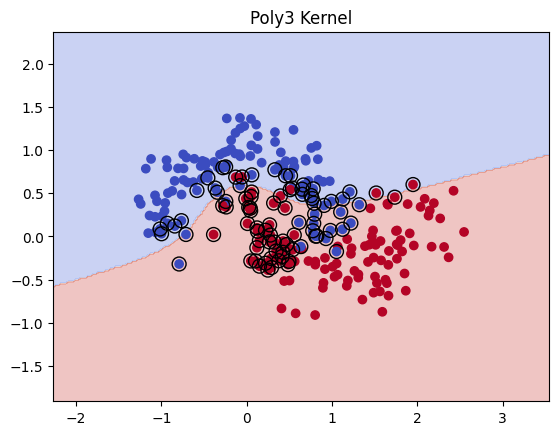

Poly4 Accuracy: 0.7166666666666667


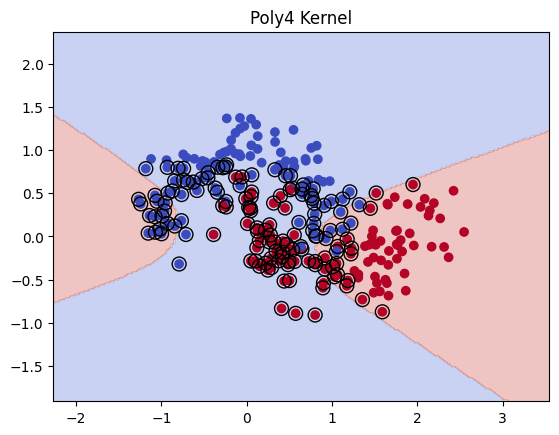

RBF Accuracy: 0.9833333333333333


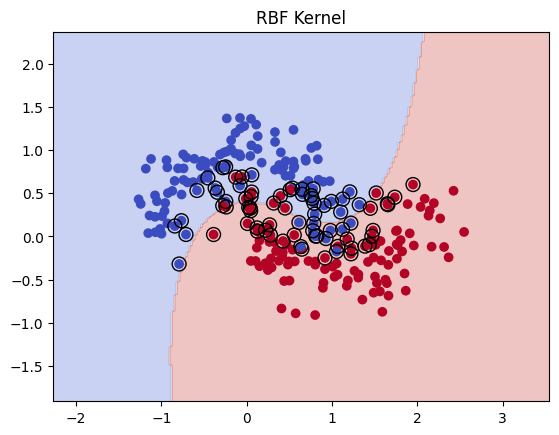

Sigmoid Accuracy: 0.65


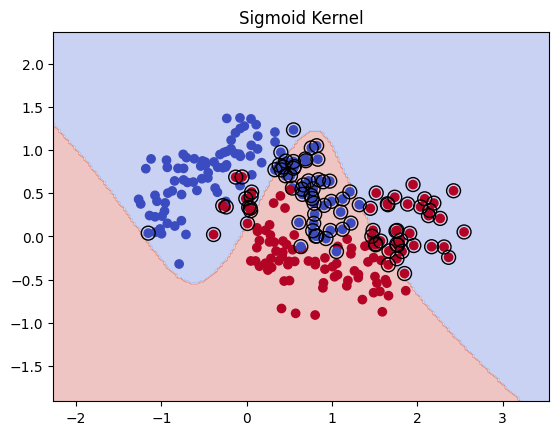

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------- Part A : Data Generation --------

# Moons dataset
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)

# Circles dataset
X_circle, y_circle = make_circles(n_samples=300, noise=0.1, factor=0.5)

# XOR dataset
np.random.seed(42)
X_xor = np.random.randn(300,2)
y_xor = np.logical_xor(X_xor[:,0]>0 , X_xor[:,1]>0)

# Plot datasets
datasets = [(X_moon,y_moon,"Moons"),(X_circle,y_circle,"Circles"),(X_xor,y_xor,"XOR")]

for X,y,title in datasets:
    plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
    plt.title(title)
    plt.show()

# -------- Part B : SVM Implementation --------

X_train,X_test,y_train,y_test=train_test_split(X_moon,y_moon,test_size=0.2)

models = {
"Linear":SVC(kernel="linear",C=1),
"Poly2":SVC(kernel="poly",degree=2,C=1),
"Poly3":SVC(kernel="poly",degree=3,C=1),
"Poly4":SVC(kernel="poly",degree=4,C=1),
"RBF":SVC(kernel="rbf",gamma=0.5,C=1),
"Sigmoid":SVC(kernel="sigmoid",C=1)
}

# -------- Part C : Visualization --------

def plot_boundary(model,X,y,title):

    model.fit(X,y)

    xx,yy=np.meshgrid(
        np.linspace(X[:,0].min()-1,X[:,0].max()+1,200),
        np.linspace(X[:,1].min()-1,X[:,1].max()+1,200)
    )

    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.3,cmap="coolwarm")
    plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")

    # support vectors
    plt.scatter(model.support_vectors_[:,0],
                model.support_vectors_[:,1],
                s=100,facecolors='none',edgecolors='k')

    plt.title(title)
    plt.show()

# Train and evaluate models
for name,model in models.items():

    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)

    print(name,"Accuracy:",acc)

    plot_boundary(model,X_train,y_train,name+" Kernel")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

# Load real dataset
digits = load_digits()
X, y = digits.data, digits.target

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# -------- One-vs-One (default SVM) --------
svm_ovo = SVC(kernel='rbf')
svm_ovo.fit(X_train,y_train)

pred_ovo = svm_ovo.predict(X_test)
print("One-vs-One Accuracy:",accuracy_score(y_test,pred_ovo))

# -------- One-vs-Rest --------
svm_ovr = OneVsRestClassifier(SVC(kernel='rbf'))
svm_ovr.fit(X_train,y_train)

pred_ovr = svm_ovr.predict(X_test)
print("One-vs-Rest Accuracy:",accuracy_score(y_test,pred_ovr))

# -------- Hyperparameter tuning --------
params = {
"C":[0.1,1,10],
"gamma":[0.01,0.1,1],
"kernel":["rbf"]
}

grid = GridSearchCV(SVC(),params,cv=3)
grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best Score:",grid.best_score_)

# -------- Custom kernel --------
def custom_kernel(X,Y):
    return (np.dot(X,Y.T)+1)**2

svm_custom = SVC(kernel=custom_kernel)
svm_custom.fit(X_train,y_train)

pred_custom = svm_custom.predict(X_test)
print("Custom Kernel Accuracy:",accuracy_score(y_test,pred_custom))

# -------- Neural Network comparison --------
nn = MLPClassifier(hidden_layer_sizes=(100,),max_iter=500)
nn.fit(X_train,y_train)

pred_nn = nn.predict(X_test)
print("Neural Network Accuracy:",accuracy_score(y_test,pred_nn))

One-vs-One Accuracy: 0.9805555555555555
One-vs-Rest Accuracy: 0.9833333333333333
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Score: 0.9812108559498957
Custom Kernel Accuracy: 0.9861111111111112
Neural Network Accuracy: 0.9777777777777777
